# BIOC0023 data analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Adding the short cuts


https://drive.google.com/drive/folders/1HlLM86kqc7tdFrFcQLbqMw9bnmrkVk3X?usp=drive_link

In [ ]:
!gsutil cp /content/drive/MyDrive/BIOC0023_25_26/lab_data/Hospital/usearch12 /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/Hospital/usearch12...
/ [1 files][  2.2 MiB/  2.2 MiB]                                                
Operation completed over 1 objects/2.2 MiB.                                      


In [ ]:
!gsutil cp /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/*.* /content/
!gsutil cp /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/primer_remove_merge.sh /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/HFD.1.raw_1.fastq.gz...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/HFD.1.raw_2.fastq.gz...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/HFD.2.raw_1.fastq.gz...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/HFD.2.raw_2.fastq.gz...
\ [4 files][ 11.2 MiB/ 11.2 MiB]                                                
==> NOTE: You are performing a sequence of gsutil operations that may
run significantly faster if you instead use gsutil -m cp ... Please
see the -m section under "gsutil help options" for further information
about when gsutil -m can be advantageous.

Copy

In [ ]:
!gsutil cp -r /content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/vsearch_outputs/ /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/vsearch_outputs/zotus.fa...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/vsearch_outputs/zotus_nochime.fa...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/vsearch_outputs/zotus_nochime_nomask.fa...
Copying file:///content/drive/MyDrive/BIOC0023_25_26/lab_data/23BD/16S_fecal/vsearch_outputs/usearch12...
- [4 files][  3.5 MiB/  3.5 MiB]                                                
==> NOTE: You are performing a sequence of gsutil operations that may
run significantly faster if you instead use gsutil -m cp ... Please
see the -m section under "gsutil help options" for further information
about w

Altering file names to make them suitable for vsearch


In [ ]:
from pathlib import Path

# folder containing files
path = Path("/content")

for f in path.glob("*.fastq.gz"):
    # split filename into parts by first occurrence of ".raw_"
    if ".raw_" in f.name:
        sample, rest = f.name.split(".raw_", 1)  # split only once
        # replace dots with underscores in the sample part
        new_name = f"{sample.replace('.', '_')}.raw_{rest}"
        new_path = path / new_name
        if f != new_path:
            print(f"Renaming: {f.name} -> {new_name}")
            f.rename(new_path)

Renaming: HFD.R.4.raw_1.fastq.gz -> HFD_R_4.raw_1.fastq.gz
Renaming: HFD.M.10.raw_2.fastq.gz -> HFD_M_10.raw_2.fastq.gz
Renaming: HFD.R.5.raw_1.fastq.gz -> HFD_R_5.raw_1.fastq.gz
Renaming: HFD.S.8.raw_1.fastq.gz -> HFD_S_8.raw_1.fastq.gz
Renaming: HFD.MRS.4.raw_2.fastq.gz -> HFD_MRS_4.raw_2.fastq.gz
Renaming: HFD.S.2.raw_2.fastq.gz -> HFD_S_2.raw_2.fastq.gz
Renaming: HFD.M.10.raw_1.fastq.gz -> HFD_M_10.raw_1.fastq.gz
Renaming: HFD.M.2.raw_1.fastq.gz -> HFD_M_2.raw_1.fastq.gz
Renaming: HFD.MRS.4.raw_1.fastq.gz -> HFD_MRS_4.raw_1.fastq.gz
Renaming: HFD.4.raw_1.fastq.gz -> HFD_4.raw_1.fastq.gz
Renaming: HFD.S.6.raw_1.fastq.gz -> HFD_S_6.raw_1.fastq.gz
Renaming: HFD.M.6.raw_1.fastq.gz -> HFD_M_6.raw_1.fastq.gz
Renaming: HFD.S.5.raw_2.fastq.gz -> HFD_S_5.raw_2.fastq.gz
Renaming: HFD.2.raw_2.fastq.gz -> HFD_2.raw_2.fastq.gz
Renaming: HFD.R.5.raw_2.fastq.gz -> HFD_R_5.raw_2.fastq.gz
Renaming: HFD.R.3.raw_2.fastq.gz -> HFD_R_3.raw_2.fastq.gz
Renaming: HFD.R.2.raw_2.fastq.gz -> HFD_R_2.raw_2.fa

Install the packages

In [ ]:
!pip install --upgrade git+https://github.com/toryn13/qiime2pandas.git

  Cloning https://github.com/toryn13/qiime2pandas.git to /tmp/pip-req-build-6b2zpi8u
  Running command git clone --filter=blob:none --quiet https://github.com/toryn13/qiime2pandas.git /tmp/pip-req-build-6b2zpi8u
  Resolved https://github.com/toryn13/qiime2pandas.git to commit 799ccf44dd2f7bd7dab32dc1c2ff6db0cfcad5c9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for qiime2pandas: filename=qiime2pandas-0.1.0-py3-none-any.whl size=13142 sha256=e14647023a2aaeaa4995435cd9e86ec96ac37b762ed87d0f91418c9e07629385
  Stored in directory: /tmp/pip-ephem-wheel-cache-787w90aa/wheels/b6/c2/d4/4e0771e64648b204f8c7a8f135ee45239a5332d328aeafc5f0
Successfully built qiime2pandas


In [ ]:
import qiime2pandas as q2p

In [ ]:
!pip install cutadapt
!sudo apt-get install vsearch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.1/281.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 10.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  vsearch
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 380 kB of archives.
After this operation, 634 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 vsearch amd64 2.21.1-1 [380 kB]
Fetched 380 kB in 1s (274 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to

In [ ]:
!chmod 777 /content/usearch12

In [ ]:
%%bash
cd /content/
chmod 777 /content/primer_remove_merge.sh
./primer_remove_merge.sh

Processing sample: HFD_1.raw
This is cutadapt 5.2 with Python 3.12.13
Command line parameters: -g CCTAYGGGRBGCASCAG -G GGACTACNNGGGTATCTAAT -o /content/trim/HFD_1.raw_1_trimmed.fastq -p /content/trim/HFD_1.raw_2_trimmed.fastq /content/HFD_1.raw_1.fastq.gz /content/HFD_1.raw_2.fastq.gz --cores=2
Processing paired-end reads on 2 cores ...

=== Summary ===

Total read pairs processed:             62,924
  Read 1 with adapter:                  62,821 (99.8%)
  Read 2 with adapter:                  62,746 (99.7%)
Pairs written (passing filters):        62,924 (100.0%)

Total basepairs processed:    31,462,000 bp
  Read 1:    15,731,000 bp
  Read 2:    15,731,000 bp
Total written (filtered):     28,133,798 bp (89.4%)
  Read 1:    14,160,011 bp
  Read 2:    13,973,787 bp

=== First read: Adapter 1 ===

Sequence: CCTAYGGGRBGCASCAG; Type: regular 5'; Length: 17; Trimmed: 62821 times

Minimum overlap: 3
No. of allowed errors:
1-9 bp: 0; 10-17 bp: 1

Overview of removed sequences
length	count	exp

Copying file:///content/usearch12...
/ [1 files][  2.2 MiB/  2.2 MiB]                                                
Operation completed over 1 objects/2.2 MiB.                                      


In [ ]:
cd /content/merged/

/content/merged


In [ ]:
%%bash
VSEARCH="vsearch"
for s in *.fastq; do
    "$VSEARCH" --fastq_eestats2 "$s" --output "${s%%.fastq}.stats"  --fastq_qmax 42
done


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading FASTQ file 100%
v

Use qiime2pandas to visualise the sequnence quality information

In [ ]:
import qiime2pandas as q2p

In [ ]:
q2p.process_stats_files('/content/merged/', 'MaxEE1')

,Length,MaxEE1,File
0,50,47807,HFD_R_10.raw_merged.stats
1,100,46964,HFD_R_10.raw_merged.stats
2,150,45763,HFD_R_10.raw_merged.stats
3,200,44072,HFD_R_10.raw_merged.stats
4,250,43130,HFD_R_10.raw_merged.stats
...,...,...,...
499,250,56681,HFD_5.raw_merged.stats
500,300,54866,HFD_5.raw_merged.stats
501,350,53902,HFD_5.raw_merged.stats
502,400,53173,HFD_5.raw_merged.stats


In [ ]:
import pandas as pd
df = pd.read_csv('/content/merged/maxEE_summary.csv')

In [ ]:
df.groupby('Length').describe()

MaxEE1                                                         \
        count          mean          std      min       25%      50%   
Length                                                                 
50       56.0  61300.107143  8216.362311  31308.0  60701.75  62225.0   
100      56.0  60223.607143  8076.741910  30727.0  59628.75  61191.5   
150      56.0  58814.964286  7894.629857  30052.0  58085.25  59846.5   
200      56.0  56940.839286  7686.826194  29128.0  56075.75  57813.5   
250      56.0  55492.946429  7524.149151  28256.0  54452.25  56387.5   
300      56.0  53825.142857  7361.879326  26800.0  52699.75  54671.5   
350      56.0  52861.928571  7255.329284  26128.0  51688.75  53691.0   
400      56.0  52186.517857  7166.145405  25783.0  51140.00  52926.0   
450      56.0      1.375000     1.287174      0.0      0.00      1.0   

                           
             75%      max  
Length                     
50      64059.00  76330.0  
100     62877.50  75166.0  
150     61332.50  73723.0  
200     59384.50  71939.0  
250     57970.75  70428.0  
300     56328.00  68668.0  
350     55431.50  67580.0  
400     54725.75  66802.0  
450         2.00      5.0

Add the seaborn library: see information here.  https://seaborn.pydata.org/examples/index.html

## Filter and global truncation

In [ ]:
cd /content/merged/

/content/merged


Change the file names

In [ ]:
%%bash
VSEARCH="vsearch"
for s in *.fastq; do
    echo "Processing file: $s"
    "$VSEARCH" --fastq_filter "$s" \
        --fastq_maxee 1 \
        --fastq_trunclen 350  \
        --fastq_qmax 42 \
        --fastq_maxns 0 \
        --fastaout "${s%%.fastq}.filtered.fasta" \
        --fasta_width 0
done

Processing file: HFD_1.raw_merged.fastq
Processing file: HFD_2.raw_merged.fastq
Processing file: HFD_3.raw_merged.fastq
Processing file: HFD_4.raw_merged.fastq
Processing file: HFD_5.raw_merged.fastq
Processing file: HFD_6.raw_merged.fastq
Processing file: HFD_M_10.raw_merged.fastq
Processing file: HFD_M_1.raw_merged.fastq
Processing file: HFD_M_2.raw_merged.fastq
Processing file: HFD_M_3.raw_merged.fastq
Processing file: HFD_M_4.raw_merged.fastq
Processing file: HFD_M_5.raw_merged.fastq
Processing file: HFD_M_6.raw_merged.fastq
Processing file: HFD_M_7.raw_merged.fastq
Processing file: HFD_M_8.raw_merged.fastq
Processing file: HFD_M_9.raw_merged.fastq
Processing file: HFD_MRS_10.raw_merged.fastq
Processing file: HFD_MRS_1.raw_merged.fastq
Processing file: HFD_MRS_2.raw_merged.fastq
Processing file: HFD_MRS_3.raw_merged.fastq
Processing file: HFD_MRS_4.raw_merged.fastq
Processing file: HFD_MRS_5.raw_merged.fastq
Processing file: HFD_MRS_6.raw_merged.fastq
Processing file: HFD_MRS_7.raw

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
43754 sequences kept (of which 43752 truncated), 10699 sequences discarded.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
51429 sequences kept (of which 51429 truncated), 9578 sequences discarded.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
53096 sequences kept (of which 53096 truncated), 8378 sequences discarded.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
56931 sequences kept (of which 56931 truncated), 8128 sequences discarded.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
53901 sequences kept (of which 53901 truncated), 9171 sequences discarded.
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/

## Dereplication

In [ ]:
%%bash
VSEARCH="vsearch"

for s in *.filtered.fasta; do
    echo "Dereplicate at sample level and relabel with sample.n for: $s"
    "$VSEARCH" --derep_fulllength "$s" \
        --strand plus \
        --output "${s%.fasta}.derep.fasta" \
        --sizeout \
        --relabel "${s%.filtered.fasta}." \
        --fasta_width 0
done


Dereplicate at sample level and relabel with sample.n for: HFD_1.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_2.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_3.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_4.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_5.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_6.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_M_10.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_M_1.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_M_2.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_M_3.raw_merged.filtered.fasta
Dereplicate at sample level and relabel with sample.n for: HFD_M_4.raw_merged.fil

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Dereplicating file HFD_1.raw_merged.filtered.fasta 100%
15313900 nt in 43754 seqs, min 350, max 350, avg 350
Sorting 100%
8551 unique sequences, avg cluster 5.1, median 1, max 11064
Writing FASTA output file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Dereplicating file HFD_2.raw_merged.filtered.fasta 100%
18000150 nt in 51429 seqs, min 350, max 350, avg 350
Sorting 100%
9672 unique sequences, avg cluster 5.3, median 1, max 6573
Writing FASTA output file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Dereplicating file HFD_3.raw_merged.filtered.fasta 100%
18583600 nt in 53096 seqs, min 350, max 350, avg 350
Sorting 100%
5586 unique sequences, avg cluster 9.5, median 1, max 16604
Writing FASTA output file 100%
vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Dereplicating 

## Pool together all the fasta files

In [ ]:
%%bash

cat *.derep.fasta > all.derep.fasta
echo "Sum of unique sequences: $(grep -c "^>" all.derep.fasta)"


Sum of unique sequences: 411061


## Dereplication of the pooled fasta file

In [ ]:
%%bash
VSEARCH="vsearch"

"$VSEARCH" --derep_fulllength all.derep.fasta \
    --sizein \
    --sizeout \
    --fasta_width 0 \
    --uc all.derep.uc \
    --output derep.fasta
echo "Unique sequences: $(grep -c "^>" derep.fasta)"


Unique sequences: 236023


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Dereplicating file all.derep.fasta 100%
143871350 nt in 411061 seqs, min 350, max 350, avg 350
Sorting 100%
236023 unique sequences, avg cluster 12.5, median 1, max 472952
Writing FASTA output file 100%
Writing uc file, first part 100%
Writing uc file, second part 100%


## Denoising steps

In [ ]:
%%bash
VSEARCH="vsearch"

"$VSEARCH" --cluster_unoise all.derep.fasta \
           --centroids zotus.fa \
            --uc uc_zotus.uc \
            --log unoise_log.txt

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file all.derep.fasta 100%
6030500 nt in 17230 seqs, min 350, max 350, avg 350
minsize 8: 393831 sequences discarded.
Masking 100%
Sorting by abundance 100%
Counting k-mers 100%
Clustering 100%
Sorting clusters 100%
Writing clusters 100%
Clusters: 1622 Size min 1, max 1729, avg 10.6
Singletons: 634, 3.7% of seqs, 39.1% of clusters


In [ ]:
%%bash

VSEARCH="vsearch"

"$VSEARCH" --sortbysize zotus.fa \
  --fasta_width 0 \
  --output sorted.fasta


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file zotus.fa 100%
567700 nt in 1622 seqs, min 350, max 350, avg 350
Getting sizes 100%
Sorting 100%
Median abundance: 20
Writing output 100%


## Chimera detection

In [ ]:
%%bash

VSEARCH="vsearch"

$VSEARCH --uchime_denovo sorted.fasta \
    --fasta_width 0 \
    --nonchimeras denovo.nonchimeras.fasta

#echo "Unique sequences after de novo chimera detection: $(grep -c "^>" denovo.nonchimeras.fasta)"


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file sorted.fasta 100%
567700 nt in 1622 seqs, min 350, max 350, avg 350
Masking 100%
Sorting by abundance 100%
Counting k-mers 100%
Detecting chimeras 100%
Found 720 (44.4%) chimeras, 884 (54.5%) non-chimeras,
and 18 (1.1%) borderline sequences in 1622 unique sequences.
Taking abundance information into account, this corresponds to
14342 (4.4%) chimeras, 314050 (95.5%) non-chimeras,
and 411 (0.1%) borderline sequences in 328803 total sequences.


## Chimera removal

In [ ]:
%%bash

VSEARCH="vsearch"

$VSEARCH --fastx_filter denovo.nonchimeras.fasta \
    --fasta_width 0 \
    --relabel OTU_ \
    --fastaout otus.fasta

echo "Number of OTUs: $(grep -c "^>" otus.fasta)"


Number of OTUs: 884


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading input file 100%
884 sequences kept (of which 0 truncated), 0 sequences discarded.


## Clustering and singleton removal

In [ ]:
%%bash
vsearch --cluster_unoise all.derep.fasta --centroids zotus.fa --uc uc_zotus.uc --log unoise_log.txt

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file all.derep.fasta 100%
6030500 nt in 17230 seqs, min 350, max 350, avg 350
minsize 8: 393831 sequences discarded.
Masking 100%
Sorting by abundance 100%
Counting k-mers 100%
Clustering 100%
Sorting clusters 100%
Writing clusters 100%
Clusters: 1622 Size min 1, max 1729, avg 10.6
Singletons: 634, 3.7% of seqs, 39.1% of clusters


In [ ]:
%%bash
vsearch --uchime3_denovo zotus.fa --nonchimeras zotus_nochime.fa --fasta_width 0 --relabel zotu --xsize --log unchime3_log.txt


vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file zotus.fa 100%
567700 nt in 1622 seqs, min 350, max 350, avg 350
Masking 100%
Sorting by abundance 100%
Counting k-mers 100%
Detecting chimeras 100%
Found 653 (40.3%) chimeras, 969 (59.7%) non-chimeras,
and 0 (0.0%) borderline sequences in 1622 unique sequences.
Taking abundance information into account, this corresponds to
11975 (3.6%) chimeras, 316828 (96.4%) non-chimeras,
and 0 (0.0%) borderline sequences in 328803 total sequences.


In [ ]:
%%bash
#Normalize to uppercase
awk 'BEGIN{FS=" "}{if(!/>/){print toupper($0)}else{print $1}}' zotus_nochime.fa > zotus_nochime_nomask.fa

#Map reads back to centroids
vsearch --usearch_global all.derep.fasta --db zotus_nochime_nomask.fa --id 0.97 --otutabout unoise3_zotu_table.txt --biomout unoise3_zotu_table.biom  --log otutab_log.txt

vsearch v2.21.1_linux_x86_64, 51.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file zotus_nochime_nomask.fa 100%
339150 nt in 969 seqs, min 350, max 350, avg 350
Masking 100%
Counting k-mers 100%
Creating k-mer index 100%
Searching 100%
Matching unique query sequences: 322760 of 411061 (78.52%)
Writing OTU table (biom 1.0) 100%
Writing OTU table (classic) 100%


## Add the Taxonomy

In [ ]:
!gsutil cp /content/drive/MyDrive/DAE2026/rdp_16s_v18.fa.gz  /content/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///content/drive/MyDrive/DAE2026/rdp_16s_v18.fa.gz...
-
Operation completed over 1 objects/6.5 MiB.                                      


In [ ]:
!gunzip /content/rdp_16s_v18.fa.gz

In [ ]:
%%bash
chmod 777 usearch12

In [ ]:
!./usearch12 -sintax /content/merged/zotus_nochime.fa -db /content/rdp_16s_v18.fa -strand both \
  -tabbedout sintax.txt -sintax_cutoff 0.8

usearch v12.0 [b1d935b], 53.5Gb RAM, 8 cores
(C) Copyright 2013-24 Robert C. Edgar.
https://drive5.com/usearch

sintax zotus_nochime.fa
00:00  70Mb ...... Loading seqs.
00:01  37Mb 100.0% Masking (fastnucleo)
00:01  38Mb 100.0% Udb seqs
00:01  38Mb 100.0% Alloc rows
00:03 152Mb 100.0% Build udb index
00:03 151Mb ...... Starting 8 threads
00:05 161Mb 100.0% Classifying 225 / 3876 predicted genus (5.8%)
00:05 161Mb ...... Finished



# Diversity Analysis


In [ ]:
!cp /content/vsearch_outputs/*.* /content/

## Import the feature table

In [ ]:
!pip install --upgrade git+https://github.com/toryn13/qiime2pandas.git


  Cloning https://github.com/toryn13/qiime2pandas.git to /tmp/pip-req-build-ydh0nqam
  Running command git clone --filter=blob:none --quiet https://github.com/toryn13/qiime2pandas.git /tmp/pip-req-build-ydh0nqam
  Resolved https://github.com/toryn13/qiime2pandas.git to commit 799ccf44dd2f7bd7dab32dc1c2ff6db0cfcad5c9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for qiime2pandas: filename=qiime2pandas-0.1.0-py3-none-any.whl size=13142 sha256=d9e6220592be2537d5f18ba8700b0960cd5bb362a6d0f5a74deeb57face7a9d6
  Stored in directory: /tmp/pip-ephem-wheel-cache-jhobo2ml/wheels/b6/c2/d4/4e0771e64648b204f8c7a8f135ee45239a5332d328aeafc5f0
Successfully built qiime2pandas


In [ ]:
import qiime2pandas as q2p

In [ ]:
import pandas as pd

In [ ]:
table=pd.read_table('/content/unoise3_zotu_table.txt', sep='\t', index_col=0)

In [ ]:
table

,HFD_1,HFD_2,HFD_3,HFD_4,HFD_5,HFD_6,HFD_MRS_1,HFD_MRS_10,HFD_MRS_2,HFD_MRS_3,...,NC_1,NC_10,NC_2,NC_3,NC_4,NC_5,NC_6,NC_7,NC_8,NC_9
#OTU ID,,,,,,,,,,,,,,,,,,,,,
zotu1,16145,3559,20815,21716,22418,16349,23553,20498,15472,19019,...,0,0,0,0,0,0,0,0,0,0
zotu10,816,9022,1935,2125,8,780,818,168,93,11,...,243,64,70,115,22,152,52,45,30,22
zotu100,0,1,0,3,8,0,0,0,0,0,...,173,2,63,2,6,599,1,0,10,41
zotu101,16,436,450,231,56,76,123,25,154,59,...,205,33,228,117,37,270,43,61,558,53
zotu102,0,46,27,171,34,16,136,13,41,34,...,501,18,205,186,59,301,1,17,29,213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zotu968,0,0,0,0,0,0,0,0,0,0,...,4,1,0,0,0,0,0,0,4,13
zotu969,0,0,0,0,0,0,0,0,0,0,...,5,3,0,0,0,0,0,2,1,31
zotu97,0,0,0,0,0,0,2,0,0,0,...,28,721,21,43,5,429,234,134,111,64


In [ ]:
table.sum(axis=0)

,0
HFD_1,38928
HFD_2,46933
HFD_3,52630
HFD_4,56126
HFD_5,53453
HFD_6,36574
HFD_MRS_1,64705
HFD_MRS_10,54746
HFD_MRS_2,54741
HFD_MRS_3,53354


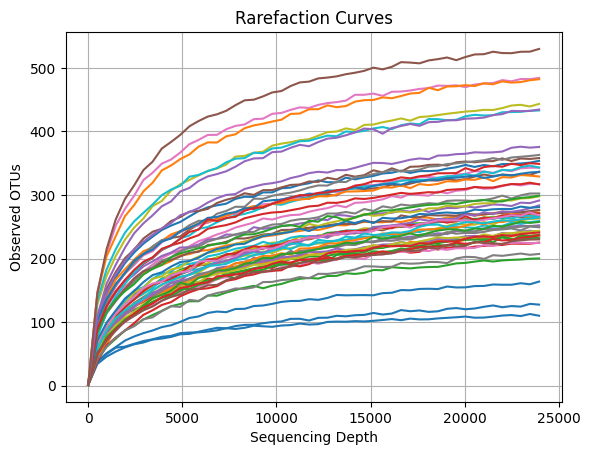

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
q2p.rarefaction_curve(table, max_depth=23957, num_iterations=10, seed=42)
plt.savefig('fig1b.png')
plt.savefig('fig1b.pdf')

Install scikit bio for the diversity analysis

TAKES 2MIN TO INSTALL

- If you wish to stop here download /content/metadata.txt and
/content/primer_clip/unoise3_zotu_table.txt

In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 122.6 MB/s eta 0:00:00


# Rarefaction

Checking the column names of the feature table

In [ ]:
import pandas as pd

In [ ]:
feature_table=pd.read_table('/content/unoise3_zotu_table.txt', sep='\t', index_col=0)

## Remove the underscores from the column name

In [ ]:
from skbio.stats import subsample_counts
from skbio import Table

Create a table object from scikitbio

In [ ]:
table = Table(feature_table.values, feature_table.index, feature_table.columns)

In [ ]:
rare_table = table.subsample(23957, seed=2025, axis='sample', with_replacement=False)

In [ ]:
rare_table

969 x 56 <class 'biom.table.Table'> with 17149 nonzero entries (31% dense)

In [ ]:
rare_table.to_dataframe().to_csv('rare_table.txt', sep='\t')

#Alpha diversity

In [ ]:
metadata=pd.read_table('/content/metadata.tsv', index_col=0)

In [ ]:
metadata

,group,mouse
sample-id,,
HFD_1,HFD,1
HFD_S_1,HFD_S,1
HFD_MRS_1,HFD_MRS,1
HFD_R_1,HFD_R,1
HFD_M_1,HFD_M,1
HFD_M_10,HFD_M,10
HFD_S_10,HFD_S,10
HFD_MRS_10,HFD_MRS,10
HFD_R_10,HFD_R,10


In [ ]:
from skbio.diversity import alpha_diversity

In [ ]:
res = alpha_diversity('shannon', rare_table)
alpha_d=pd.DataFrame(res, columns=['shannon'])

In [ ]:
res = pd.merge(alpha_d, metadata, left_index=True, right_index=True)

remove positive

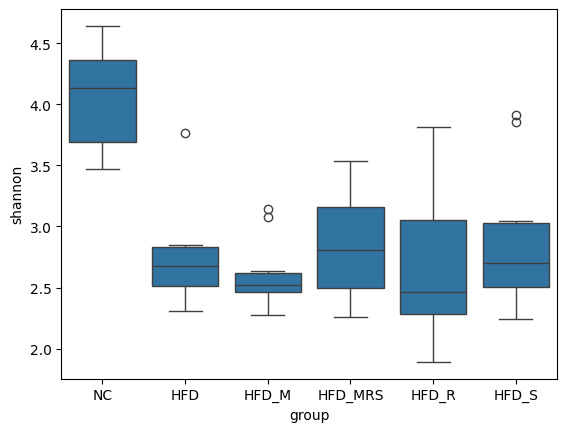

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ["NC", "HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]  # your desired order

sns.boxplot(x="group", y="shannon", data=res, order=order)

plt.savefig('fig2.png')
plt.savefig('fig2.pdf')

In [ ]:
from scipy.stats import mannwhitneyu
mannwhitneyu(res.shannon[res.group=='NC'], res.shannon[res.group=='HFD'])

MannwhitneyuResult(statistic=np.float64(56.0), pvalue=np.float64(0.002997002997002997))

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import MultiComparison

In [ ]:
multi_comp_shannon = MultiComparison(res['shannon'], res['group'])
result_shannon = multi_comp_shannon.allpairtest(mannwhitneyu, method='Holm')

In [ ]:
print("Shannon Entropy Comparison Results:")
print(result_shannon[0])

Shannon Entropy Comparison Results:
Test Multiple Comparison mannwhitneyu 
FWER=0.05 method=Holm
alphacSidak=0.00, alphacBonf=0.003
 group1  group2 stat  pval  pval_corr reject
--------------------------------------------
    HFD   HFD_M 38.0 0.4278       1.0  False
    HFD HFD_MRS 27.0 0.7925       1.0  False
    HFD   HFD_R 38.0 0.4278       1.0  False
    HFD   HFD_S 27.0 0.7925       1.0  False
    HFD      NC  4.0  0.003     0.033   True
  HFD_M HFD_MRS 32.0 0.1859       1.0  False
  HFD_M   HFD_R 54.0 0.7913       1.0  False
  HFD_M   HFD_S 35.0  0.273       1.0  False
  HFD_M      NC  0.0 0.0002    0.0027   True
HFD_MRS   HFD_R 64.0 0.3075       1.0  False
HFD_MRS   HFD_S 52.0 0.9097       1.0  False
HFD_MRS      NC  1.0 0.0002    0.0034   True
  HFD_R   HFD_S 33.0 0.2123       1.0  False
  HFD_R      NC  4.0 0.0006    0.0076   True
  HFD_S      NC  8.0 0.0017    0.0205   True
--------------------------------------------


#Beta diversity

Calculate the distances using the normalised tables

In [ ]:
from skbio.diversity import beta_diversity

In [ ]:
feature_dist = beta_diversity('jaccard', rare_table)

In [ ]:
from skbio.stats.ordination import pcoa

In [ ]:
pc = pcoa(feature_dist, number_of_dimensions=10)

Variation for each component in the data, PC1 shows the most variation.

In [ ]:
pc.proportion_explained

,0
PC1,0.170248
PC2,0.086563
PC3,0.082374
PC4,0.067137
PC5,0.051997
PC6,0.045470
PC7,0.040234
PC8,0.037690
PC9,0.034446
PC10,0.032668


## These are the coordinates to plot.

In [ ]:
pc.samples.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
HFD_1,-0.141134,-0.415295,-0.062833,-0.089319,-0.039432,0.071907,-0.129220,-0.020072,-0.112158,0.125827
HFD_2,-0.072556,-0.007142,0.019422,0.061531,-0.055303,0.094999,-0.089401,0.102185,0.028397,0.005485
HFD_3,-0.046062,0.064596,0.135807,-0.162112,-0.013811,-0.041568,-0.103531,-0.017912,0.069363,0.209367
HFD_4,-0.077382,-0.133931,0.018194,0.063277,-0.026637,0.114822,-0.136015,0.099425,0.072022,0.058995
HFD_5,-0.066869,0.009685,0.155287,-0.174495,0.067920,-0.057595,-0.057701,-0.051591,0.041233,0.186370


In [ ]:
metadata = metadata.reindex(pc.samples.index)

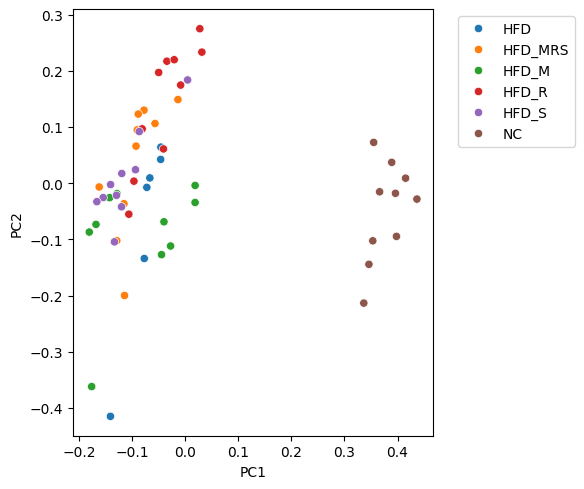

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

ax = sns.scatterplot(
    x=pc.samples.PC1,
    y=pc.samples.PC2,
    hue=metadata.group
)

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.savefig('fig3a.png', bbox_inches='tight')
plt.savefig('fig3a.pdf', bbox_inches='tight')

In [ ]:
from skbio.stats.distance import permanova

In [ ]:
permanova(feature_dist,metadata.group)

,PERMANOVA results
method name,PERMANOVA
test statistic name,pseudo-F
sample size,56
number of groups,6
test statistic,4.98891
p-value,0.001
number of permutations,999


#Taxonomy

In [ ]:
sintax=pd.read_table("/content/sintax.txt", index_col=0, header=None)

In [ ]:
sintax

,1,2,3
0,,,
zotu8,"d:Bacteria(1.0000),p:Verrucomicrobia(1.0000),c...",+,"d:Bacteria,p:Verrucomicrobia,c:Verrucomicrobia..."
zotu1,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Erys...",+,"d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:E..."
zotu2,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Erys...",+,"d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:E..."
zotu7,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Baci...",+,"d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacil..."
zotu3,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Baci...",+,"d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacil..."
...,...,...,...
zotu965,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Clos...",+,"d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostri..."
zotu966,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Clos...",+,"d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostri..."
zotu968,"d:Bacteria(1.0000),p:Firmicutes(1.0000),c:Clos...",+,"d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostri..."


In [ ]:
taxa = pd.read_csv("sintax.txt", sep='\t', header=None, names=['ID', 'TaxonomyDetails'], usecols=[0, 3])
taxa[['kingdom', 'phylum', 'class', 'order', 'family', 'genus']]=taxa['TaxonomyDetails'].str.split(',', expand=True)
taxa.drop(columns=['TaxonomyDetails'], inplace=True)

In [ ]:
taxa.index=taxa.ID
taxa.drop(columns=['ID'], inplace=True)

In [ ]:
taxa

,kingdom,phylum,class,order,family,genus
ID,,,,,,
zotu8,d:Bacteria,p:Verrucomicrobia,c:Verrucomicrobiae,o:Verrucomicrobiales,f:Akkermansiaceae,g:Akkermansia
zotu1,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Faecalibaculum
zotu2,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Dubosiella
zotu7,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus
zotu3,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus
...,...,...,...,...,...,...
zotu965,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,None
zotu966,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Ruminococcaceae,None
zotu968,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,None


In [ ]:
import pandas as pd

In [ ]:
taxa.to_csv('taxonomy.txt', sep='\t')

In [ ]:
taxa=pd.read_table('taxonomy.txt', index_col=0)

In [ ]:
feature_table=pd.read_table('rare_table.txt', index_col=0)

In [ ]:
taxa

,kingdom,phylum,class,order,family,genus
ID,,,,,,
zotu8,d:Bacteria,p:Verrucomicrobia,c:Verrucomicrobiae,o:Verrucomicrobiales,f:Akkermansiaceae,g:Akkermansia
zotu1,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Faecalibaculum
zotu2,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Dubosiella
zotu7,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus
zotu3,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus
...,...,...,...,...,...,...
zotu965,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,NaN
zotu966,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Ruminococcaceae,NaN
zotu968,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,NaN


In [ ]:
import pandas as pd

# Set the desired taxonomic level
desired_taxonomic_level = 'phylum'  # Change this to the desired level

# Read rare table
table = pd.read_table("/content/rare_table.txt", index_col=[0])
rel_table = table / table[table.columns].sum() * 100

# Read taxonomy information
taxon = pd.read_table("/content/taxonomy.txt", index_col=0)

# Merge taxonomy and rare table
taxa_results = pd.merge(taxon, rel_table, left_index=True, right_index=True)

# Extract numeric sample columns (assuming taxonomy columns are the first 6)
numeric_cols = taxa_results.columns[6:]


# Group by phylum and sum the numeric values
sumtax = taxa_results.groupby("phylum")[numeric_cols].sum().T







In [ ]:
sumtax.columns

Index(['p:Actinobacteria', 'p:Bacteroidetes', 'p:Campilobacterota',
       'p:Candidatus_Saccharibacteria', 'p:Deferribacteres', 'p:Firmicutes',
       'p:Proteobacteria', 'p:Tenericutes', 'p:Verrucomicrobia'],
      dtype='object', name='phylum')

In [ ]:
taxa_results

,kingdom,phylum,class,order,family,genus,HFD_1,HFD_2,HFD_3,HFD_4,...,NC_1,NC_10,NC_2,NC_3,NC_4,NC_5,NC_6,NC_7,NC_8,NC_9
zotu8,d:Bacteria,p:Verrucomicrobia,c:Verrucomicrobiae,o:Verrucomicrobiales,f:Akkermansiaceae,g:Akkermansia,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
zotu1,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Faecalibaculum,41.457612,7.601119,39.499937,38.932254,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
zotu2,d:Bacteria,p:Firmicutes,c:Erysipelotrichia,o:Erysipelotrichales,f:Erysipelotrichaceae,g:Dubosiella,0.000000,0.004174,7.329799,0.004174,...,0.020871,3.093042,0.584380,0.054264,0.880745,0.154443,4.503903,4.683391,0.000000,0.288016
zotu7,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus,0.000000,0.000000,0.000000,0.000000,...,0.930834,6.499144,0.722127,0.179488,0.129399,0.592729,2.834245,6.486622,26.672789,2.446049
zotu3,d:Bacteria,p:Firmicutes,c:Bacilli,o:Lactobacillales,f:Lactobacillaceae,g:Lactobacillus,9.471136,3.527153,4.633301,0.070960,...,1.022666,17.402012,1.010143,0.605251,0.459156,0.839003,16.345953,17.602371,1.110323,7.914180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zotu965,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016697,0.004174
zotu966,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Ruminococcaceae,NaN,0.000000,0.012522,0.004174,0.000000,...,0.008348,0.008348,0.008348,0.012522,0.000000,0.004174,0.000000,0.000000,0.016697,0.025045
zotu968,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,NaN,0.000000,0.000000,0.000000,0.000000,...,0.008348,0.004174,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008348,0.025045
zotu967,d:Bacteria,p:Firmicutes,c:Clostridia,o:Clostridiales,f:Lachnospiraceae,NaN,0.000000,0.004174,0.000000,0.000000,...,0.000000,0.004174,0.008348,0.012522,0.000000,0.000000,0.000000,0.000000,0.025045,0.012522


In [ ]:
sumtax

phylum,p:Actinobacteria,p:Bacteroidetes,p:Campilobacterota,p:Candidatus_Saccharibacteria,p:Deferribacteres,p:Firmicutes,p:Proteobacteria,p:Tenericutes,p:Verrucomicrobia
HFD_1,15.402596,9.850983,0.000000,0.000000,0.000000,74.683808,0.062612,0.000000,0.000000
HFD_2,4.119881,35.367533,0.037567,0.000000,0.066786,54.455900,5.309513,0.000000,0.000000
HFD_3,2.696498,20.286346,0.288016,0.054264,0.070960,75.990316,0.267145,0.000000,0.000000
HFD_4,14.755604,13.048378,0.066786,0.029219,0.242100,67.107735,4.462161,0.000000,0.000000
HFD_5,3.055474,11.240973,0.000000,0.012522,0.108528,84.601578,0.813958,0.000000,0.000000
HFD_6,2.625537,12.476520,0.058438,0.045916,0.029219,84.405393,0.058438,0.000000,0.000000
HFD_MRS_1,6.457403,8.728138,0.000000,0.079309,0.438285,81.813249,1.348249,0.000000,0.000000
HFD_MRS_10,4.599908,4.457987,0.025045,0.037567,0.133573,90.065534,0.317235,0.000000,0.020871
HFD_MRS_2,6.787160,8.235589,0.000000,0.020871,0.020871,84.188337,0.325583,0.000000,0.000000
HFD_MRS_3,2.863464,9.471136,0.000000,0.033393,0.075135,86.972492,0.313061,0.000000,0.000000


In [ ]:
sumtax = pd.merge(metadata, sumtax, left_index=True, right_index=True)

In [ ]:
sumtax

,group,mouse,p:Actinobacteria,p:Bacteroidetes,p:Campilobacterota,p:Candidatus_Saccharibacteria,p:Deferribacteres,p:Firmicutes,p:Proteobacteria,p:Tenericutes,p:Verrucomicrobia
HFD_1,HFD,1,15.402596,9.850983,0.000000,0.000000,0.000000,74.683808,0.062612,0.000000,0.000000
HFD_2,HFD,2,4.119881,35.367533,0.037567,0.000000,0.066786,54.455900,5.309513,0.000000,0.000000
HFD_3,HFD,3,2.696498,20.286346,0.288016,0.054264,0.070960,75.990316,0.267145,0.000000,0.000000
HFD_4,HFD,4,14.755604,13.048378,0.066786,0.029219,0.242100,67.107735,4.462161,0.000000,0.000000
HFD_5,HFD,5,3.055474,11.240973,0.000000,0.012522,0.108528,84.601578,0.813958,0.000000,0.000000
HFD_6,HFD,6,2.625537,12.476520,0.058438,0.045916,0.029219,84.405393,0.058438,0.000000,0.000000
HFD_MRS_1,HFD_MRS,1,6.457403,8.728138,0.000000,0.079309,0.438285,81.813249,1.348249,0.000000,0.000000
HFD_MRS_10,HFD_MRS,10,4.599908,4.457987,0.025045,0.037567,0.133573,90.065534,0.317235,0.000000,0.020871
HFD_MRS_2,HFD_MRS,2,6.787160,8.235589,0.000000,0.020871,0.020871,84.188337,0.325583,0.000000,0.000000
HFD_MRS_3,HFD_MRS,3,2.863464,9.471136,0.000000,0.033393,0.075135,86.972492,0.313061,0.000000,0.000000


In [ ]:
sumtax_grouped = sumtax.groupby(['group']).mean()
sumtax_grouped['group'] = sumtax_grouped.index

In [ ]:
# Melt the DataFrame
#Set the level of "OTHER"
#Chage first letter to g for genus p for phylum
taxabar = pd.melt(sumtax_grouped, id_vars=['group'], value_vars=sumtax_grouped.filter(regex='p:'), var_name='Taxa', value_name='Abs')
taxabar.loc[taxabar['Abs'] < 0.5, 'Taxa'] = 'Other'
taxabar_aggregated = taxabar.groupby(['group', 'Taxa']).sum().reset_index()

<Figure size 1000x600 with 0 Axes>

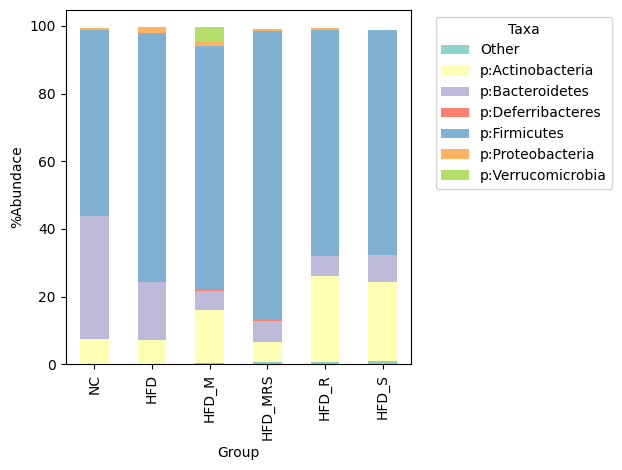

<Figure size 640x480 with 0 Axes>

In [ ]:
# Pivot the DataFrame to have 'Taxa' as columns
taxabar_pivoted = taxabar_aggregated.pivot(index='group', columns='Taxa', values='Abs').fillna(0)

# Set a custom color palette
custom_palette = sns.color_palette("Set3", n_colors=len(taxabar_pivoted.columns))
# Define desired order
order = ["NC", "HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]

# Reindex the dataframe
taxabar_pivoted = taxabar_pivoted.reindex(order)
# Create a stacked barplot
plt.figure(figsize=(10, 6))
taxabar_pivoted.plot(kind='bar', stacked=True, color=custom_palette)

# Customize the plot
plt.xlabel('Group')
plt.ylabel('%Abundace')
plt.legend(title='Taxa', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

plt.savefig('fig4a.png')
plt.savefig('fig4a.pdf')


<Figure size 1000x600 with 0 Axes>

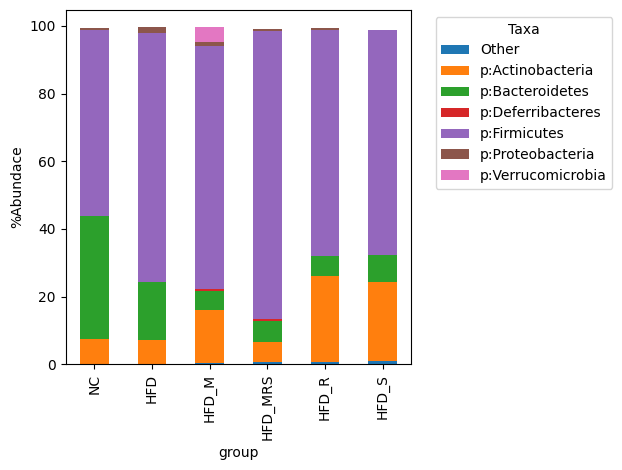

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Set a custom color palette
custom_palette = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # lime
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green
    '#ff9896',  # light red
    '#c5b0d5'   # light purple
]

# Create a stacked barplot using Seaborn
plt.figure(figsize=(10, 6))
order = ["NC", "HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]

# Reindex the dataframe
taxabar_pivoted = taxabar_pivoted.reindex(order)
taxabar_pivoted.plot(kind='bar', stacked=True, color=custom_palette)

# Customize the plot
plt.xlabel('group')
plt.ylabel('%Abundace')
plt.legend(title='Taxa', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()




plt.tight_layout()

plt.savefig('fig4.png')
plt.savefig('fig4.pdf')
# Show the plot
plt.show()


## Genus plots

In [ ]:
import pandas as pd

# Set the desired taxonomic level
desired_taxonomic_level = 'genus'  # Change this to the desired level

# Read rare table
table = pd.read_table("/content/rare_table.txt", index_col=[0])
rel_table = table / table[table.columns].sum() * 100

# Read taxonomy information
taxon = pd.read_table("/content/taxonomy.txt", index_col=0)

# Merge taxonomy and rare table
taxa_results = pd.merge(taxon, rel_table, left_index=True, right_index=True)

# Extract numeric sample columns (assuming taxonomy columns are the first 6)
numeric_cols = taxa_results.columns[6:]


# Group by phylum and sum the numeric values
sumtax = taxa_results.groupby("genus")[numeric_cols].sum().T







In [ ]:
sumtax = pd.merge(metadata, sumtax, left_index=True, right_index=True)

In [ ]:
merged_taxa_counts = pd.merge(taxa, feature_table, left_index=True, right_index=True)

In [ ]:
merged_taxa_counts.columns

Index(['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'HFD_1',
       'HFD_2', 'HFD_3', 'HFD_4', 'HFD_5', 'HFD_6', 'HFD_MRS_1', 'HFD_MRS_10',
       'HFD_MRS_2', 'HFD_MRS_3', 'HFD_MRS_4', 'HFD_MRS_5', 'HFD_MRS_6',
       'HFD_MRS_7', 'HFD_MRS_8', 'HFD_MRS_9', 'HFD_M_1', 'HFD_M_10', 'HFD_M_2',
       'HFD_M_3', 'HFD_M_4', 'HFD_M_5', 'HFD_M_6', 'HFD_M_7', 'HFD_M_8',
       'HFD_M_9', 'HFD_R_1', 'HFD_R_10', 'HFD_R_2', 'HFD_R_3', 'HFD_R_4',
       'HFD_R_5', 'HFD_R_6', 'HFD_R_7', 'HFD_R_8', 'HFD_R_9', 'HFD_S_1',
       'HFD_S_10', 'HFD_S_2', 'HFD_S_3', 'HFD_S_4', 'HFD_S_5', 'HFD_S_6',
       'HFD_S_7', 'HFD_S_8', 'HFD_S_9', 'NC_1', 'NC_10', 'NC_2', 'NC_3',
       'NC_4', 'NC_5', 'NC_6', 'NC_7', 'NC_8', 'NC_9'],
      dtype='object')

In [ ]:
df = pd.DataFrame(merged_taxa_counts)
result = q2p.tax_glom_table( merged_taxa_counts, "genus", sample_indices=range(6, 62))

In [ ]:
# Group by
#sumtax.drop(columns=['Sample Name in Report'], inplace=True)
sumtax_grouped = sumtax.groupby(['group']).mean()
sumtax_grouped['group'] = sumtax_grouped.index



In [ ]:
# Melt the DataFrame
#Set the level of "OTHER"
#Chage first letter to g for genus p for phylum
taxabar = pd.melt(sumtax_grouped, id_vars=['group'], value_vars=sumtax_grouped.filter(regex='g:'), var_name='Taxa', value_name='Abs')
taxabar.loc[taxabar['Abs'] < 1, 'Taxa'] = 'Other'
taxabar_aggregated = taxabar.groupby(['group', 'Taxa']).sum().reset_index()

<Figure size 1000x600 with 0 Axes>

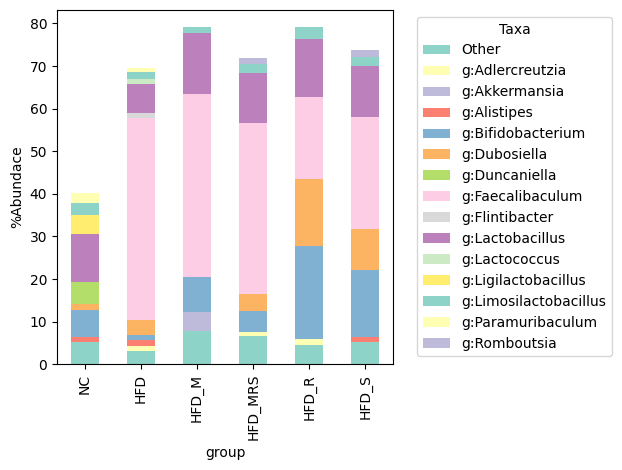

<Figure size 640x480 with 0 Axes>

In [ ]:
# Pivot the DataFrame to have 'Taxa' as columns
taxabar_pivoted = taxabar_aggregated.pivot(index='group', columns='Taxa', values='Abs').fillna(0)

# Set a custom color palette
custom_palette = sns.color_palette("Set3", n_colors=len(taxabar_pivoted.columns))

# Create a stacked barplot using Seaborn
plt.figure(figsize=(10, 6))
order = ["NC", "HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]

# Reindex the dataframe
taxabar_pivoted = taxabar_pivoted.reindex(order)
taxabar_pivoted.plot(kind='bar', stacked=True, color=custom_palette)

# Customize the plot
plt.xlabel('group')
plt.ylabel('%Abundace')
plt.legend(title='Taxa', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

plt.savefig('fig4a.png')
plt.savefig('fig4a.pdf')


## Phylum plots

In [ ]:
df = pd.DataFrame(merged_taxa_counts)
result = q2p.tax_glom_table( merged_taxa_counts, "phylum", sample_indices=range(6, 62))

In [ ]:
melted_df = pd.melt(result, id_vars=['phylum'], var_name='sample_id', value_name='Value')

In [ ]:
metadata['sample_id']=metadata.index

In [ ]:
merged_df = pd.merge(melted_df, metadata, on='sample_id')

In [ ]:
merged_df

,phylum,sample_id,Value,group,mouse
0,p:Actinobacteria,HFD_1,3690.0,HFD,1
1,p:Bacteroidetes,HFD_1,2360.0,HFD,1
2,p:Campilobacterota,HFD_1,0.0,HFD,1
3,p:Candidatus_Saccharibacteria,HFD_1,0.0,HFD,1
4,p:Deferribacteres,HFD_1,0.0,HFD,1
...,...,...,...,...,...
499,p:Deferribacteres,NC_9,17.0,NC,9
500,p:Firmicutes,NC_9,18786.0,NC,9
501,p:Proteobacteria,NC_9,450.0,NC,9
502,p:Tenericutes,NC_9,24.0,NC,9


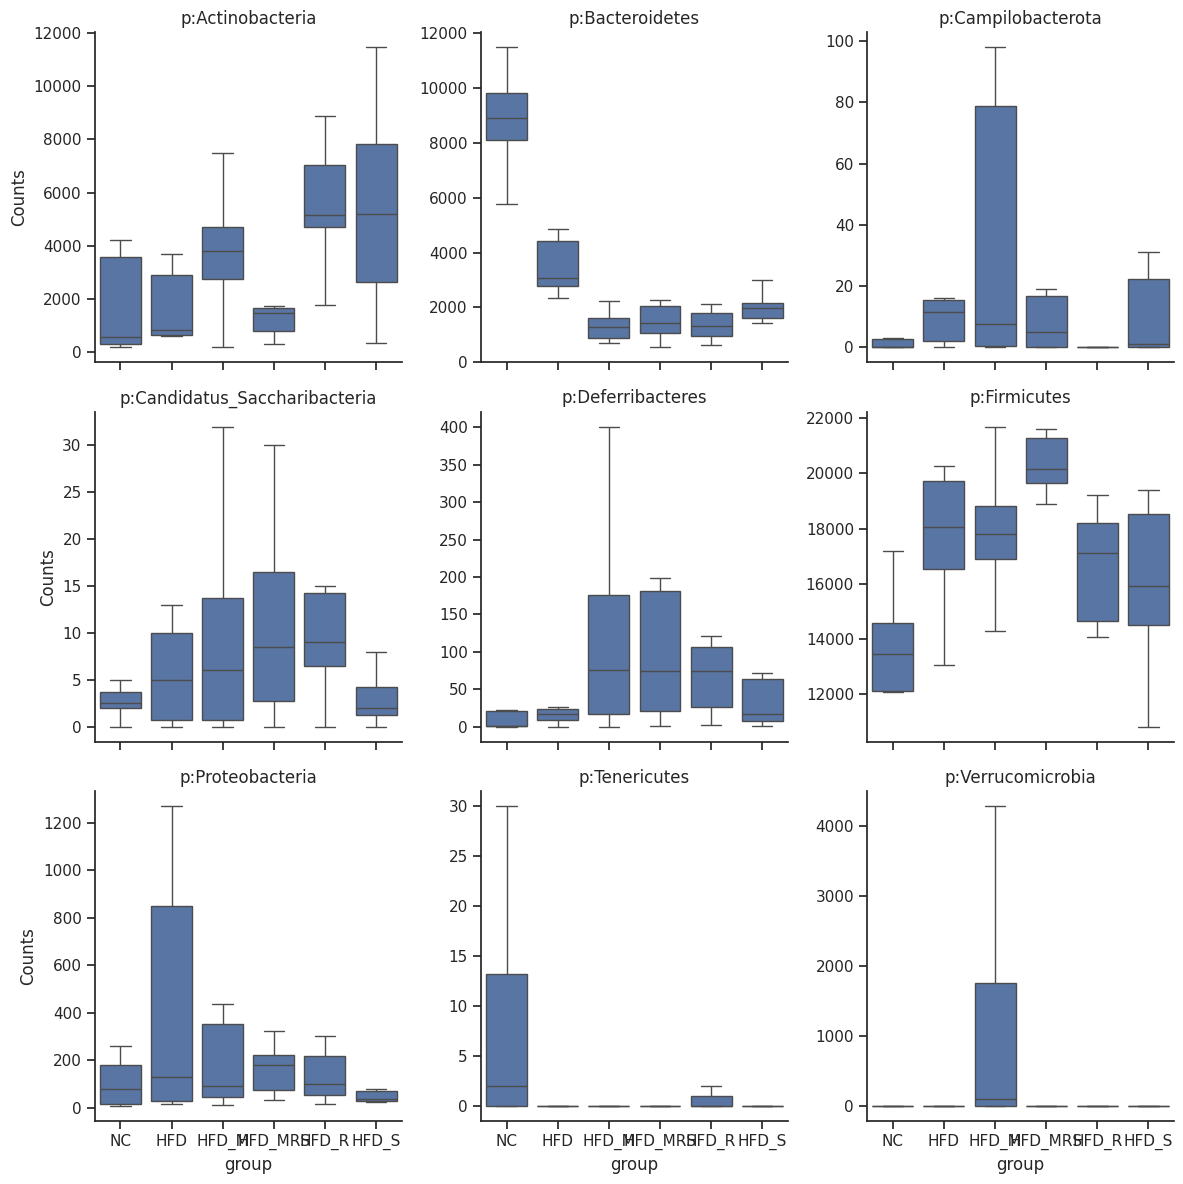

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="white")
sns.set_style('ticks')

order = ["NC", "HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]

g = sns.FacetGrid(merged_df, col="phylum", col_wrap=3, height=4, sharey=False)

g.map_dataframe(
    sns.boxplot,
    x="group",
    y="Value",
    order=order,
    showfliers=False
)

g.set_axis_labels("group", "Counts")
g.set_titles("{col_name}")
g.tight_layout()

plt.show()




In [ ]:
import pandas as pd
from scipy.stats import kruskal
from collections import defaultdict

df = pd.DataFrame(merged_df)


# Separate data by phylum
phylum_groups = df.groupby('phylum')

# Prepare a dictionary to store Kruskal-Wallis test results
kruskal_results = defaultdict(dict)

for phylum, group_data in phylum_groups:
    # Check if there are at least two different layers to compare
    if group_data['group'].nunique() > 1:
        # Perform Kruskal-Wallis test
        stat, p_value = kruskal(*[group['Value'] for name, group in group_data.groupby('group')])
        kruskal_results[phylum]['Statistic'] = stat
        kruskal_results[phylum]['p-value'] = p_value
    else:
        kruskal_results[phylum]['Statistic'] = None
        kruskal_results[phylum]['p-value'] = None

# Convert results to DataFrame for easier viewing
kruskal_results_df = pd.DataFrame(kruskal_results).T.reset_index().rename(columns={'index': 'Phylum'})

print(kruskal_results_df)

                          Phylum  Statistic   p-value
0               p:Actinobacteria  23.431830  0.000279
1                p:Bacteroidetes  35.301754  0.000001
2             p:Campilobacterota  12.368910  0.030068
3  p:Candidatus_Saccharibacteria   7.318327  0.198022
4              p:Deferribacteres  10.224552  0.069117
5                   p:Firmicutes  25.740602  0.000100
6               p:Proteobacteria   4.352529  0.499854
7                  p:Tenericutes  20.539795  0.000989
8              p:Verrucomicrobia  18.108136  0.002814


In [ ]:
selected_phyla = ['p:Firmicutes']

# Remove leading/trailing whitespaces
merged_df['phylum'] = merged_df['phylum'].str.strip()

# Filter the DataFrame based on selected phyla
filtered_df = merged_df[merged_df['phylum'].isin(selected_phyla)]


In [ ]:
filtered_df

,phylum,sample_id,Value,group,mouse
5,p:Firmicutes,HFD_1,17892.0,HFD,1
14,p:Firmicutes,HFD_2,13046.0,HFD,2
23,p:Firmicutes,HFD_3,18205.0,HFD,3
32,p:Firmicutes,HFD_4,16077.0,HFD,4
41,p:Firmicutes,HFD_5,20268.0,HFD,5
50,p:Firmicutes,HFD_6,20221.0,HFD,6
59,p:Firmicutes,HFD_MRS_1,19600.0,HFD_MRS,1
68,p:Firmicutes,HFD_MRS_10,21577.0,HFD_MRS,10
77,p:Firmicutes,HFD_MRS_2,20169.0,HFD_MRS,2
86,p:Firmicutes,HFD_MRS_3,20836.0,HFD_MRS,3


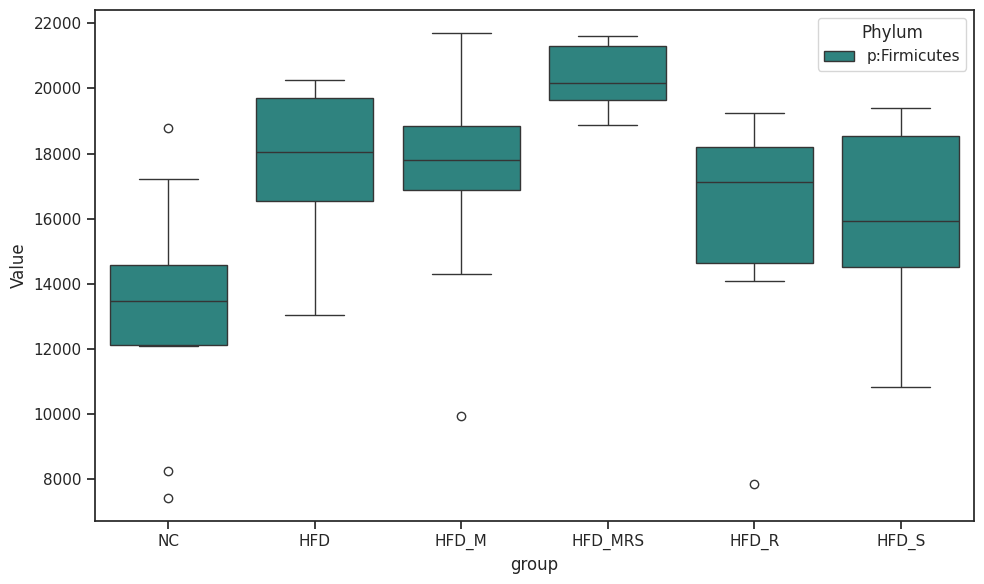

In [ ]:
# Set seaborn style
sns.set(style="white")
sns.set_style('ticks')
# Box plot using seaborn
plt.figure(figsize=(10, 6))

box_plot = sns.boxplot(x='group', y='Value', hue='phylum', data=filtered_df, palette='viridis', order=order)

# Customize the plot

plt.xlabel('group')
plt.ylabel('Value')
plt.legend(title='Phylum')
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
melted_df

,phylum,sample_id,Value
0,p:Actinobacteria,HFD_1,3690.0
1,p:Bacteroidetes,HFD_1,2360.0
2,p:Campilobacterota,HFD_1,0.0
3,p:Candidatus_Saccharibacteria,HFD_1,0.0
4,p:Deferribacteres,HFD_1,0.0
...,...,...,...
499,p:Deferribacteres,NC_9,17.0
500,p:Firmicutes,NC_9,18786.0
501,p:Proteobacteria,NC_9,450.0
502,p:Tenericutes,NC_9,24.0


In [ ]:
# Subset data for Firmicutes and Bacteroidetes
firmicutes = melted_df[melted_df["phylum"] == "p:Firmicutes"].copy()
bacteroidetes = melted_df[melted_df["phylum"] == "p:Bacteroidetes"].copy()

# Sum values per sample_id
firmicutes_sum = firmicutes.groupby("sample_id")["Value"].sum()
bacteroidetes_sum = bacteroidetes.groupby("sample_id")["Value"].sum()

# Calculate Firmicutes-to-Bacteroidetes ratio
fb_ratio = firmicutes_sum / bacteroidetes_sum
fb_ratio = fb_ratio.reset_index().rename(columns={0: "FB_ratio"})
fb_ratio.index=fb_ratio['sample_id']
fb_ratio.drop(columns=['sample_id'], inplace=True)
# Merge with metadata for plotting
fb_ratio = fb_ratio.merge(metadata, right_index=True, left_index=True)

In [ ]:
fb_ratio

,Value,group,mouse
sample_id,,,
HFD_1,7.581356,HFD,1
HFD_2,1.539714,HFD,2
HFD_3,3.745885,HFD,3
HFD_4,5.142994,HFD,4
HFD_5,7.526179,HFD,5
HFD_6,6.765139,HFD,6
HFD_MRS_1,9.373505,HFD_MRS,1
HFD_MRS_10,20.203184,HFD_MRS,10
HFD_MRS_2,10.222504,HFD_MRS,2


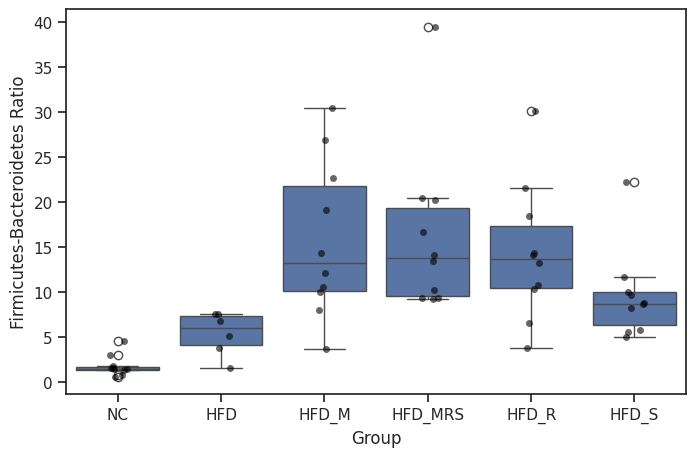

In [ ]:
# Plot the F/B ratio
plt.figure(figsize=(8, 5))
plot_order = ["NC","HFD", "HFD_M", "HFD_MRS", "HFD_R", "HFD_S"]
sns.boxplot(x="group", y="Value", data=fb_ratio, order=plot_order)
sns.stripplot(x="group", y="Value", data=fb_ratio, color="black", alpha=0.6, jitter=True)
plt.ylabel("Firmicutes-Bacteroidetes Ratio")
plt.xlabel("Group")

plt.grid(False)

# Save the figure
plt.savefig("FB_ratio.png", dpi=300)
plt.show()

# Abundnace type testing

In [ ]:
from skbio.stats.composition import clr, ilr, centralize, dirmult_ttest, ancom, multi_replace

In [ ]:
feature_table =pd.read_csv('rare_table.txt', sep='\t', index_col=0)

In [ ]:
abundance_data = feature_table.T

MAKE SURE THE INDEXES MATCH!!!!

In [ ]:
abundance_data.index

Index(['HFD_1', 'HFD_2', 'HFD_3', 'HFD_4', 'HFD_5', 'HFD_6', 'HFD_MRS_1',
       'HFD_MRS_10', 'HFD_MRS_2', 'HFD_MRS_3', 'HFD_MRS_4', 'HFD_MRS_5',
       'HFD_MRS_6', 'HFD_MRS_7', 'HFD_MRS_8', 'HFD_MRS_9', 'HFD_M_1',
       'HFD_M_10', 'HFD_M_2', 'HFD_M_3', 'HFD_M_4', 'HFD_M_5', 'HFD_M_6',
       'HFD_M_7', 'HFD_M_8', 'HFD_M_9', 'HFD_R_1', 'HFD_R_10', 'HFD_R_2',
       'HFD_R_3', 'HFD_R_4', 'HFD_R_5', 'HFD_R_6', 'HFD_R_7', 'HFD_R_8',
       'HFD_R_9', 'HFD_S_1', 'HFD_S_10', 'HFD_S_2', 'HFD_S_3', 'HFD_S_4',
       'HFD_S_5', 'HFD_S_6', 'HFD_S_7', 'HFD_S_8', 'HFD_S_9', 'NC_1', 'NC_10',
       'NC_2', 'NC_3', 'NC_4', 'NC_5', 'NC_6', 'NC_7', 'NC_8', 'NC_9'],
      dtype='object')

In [ ]:
metadata=pd.read_table('metadata.tsv', sep='\t', index_col=0)

In [ ]:
metadata = metadata.reindex(abundance_data.index)

In [ ]:
metadata.index

Index(['HFD_1', 'HFD_2', 'HFD_3', 'HFD_4', 'HFD_5', 'HFD_6', 'HFD_MRS_1',
       'HFD_MRS_10', 'HFD_MRS_2', 'HFD_MRS_3', 'HFD_MRS_4', 'HFD_MRS_5',
       'HFD_MRS_6', 'HFD_MRS_7', 'HFD_MRS_8', 'HFD_MRS_9', 'HFD_M_1',
       'HFD_M_10', 'HFD_M_2', 'HFD_M_3', 'HFD_M_4', 'HFD_M_5', 'HFD_M_6',
       'HFD_M_7', 'HFD_M_8', 'HFD_M_9', 'HFD_R_1', 'HFD_R_10', 'HFD_R_2',
       'HFD_R_3', 'HFD_R_4', 'HFD_R_5', 'HFD_R_6', 'HFD_R_7', 'HFD_R_8',
       'HFD_R_9', 'HFD_S_1', 'HFD_S_10', 'HFD_S_2', 'HFD_S_3', 'HFD_S_4',
       'HFD_S_5', 'HFD_S_6', 'HFD_S_7', 'HFD_S_8', 'HFD_S_9', 'NC_1', 'NC_10',
       'NC_2', 'NC_3', 'NC_4', 'NC_5', 'NC_6', 'NC_7', 'NC_8', 'NC_9'],
      dtype='object')

In [ ]:
res = dirmult_ttest(abundance_data, metadata['group'],
                    treatment='HFD', reference='NC',
                    draws=1000)

In [ ]:
res

,T-statistic,Log2(FC),CI(2.5),CI(97.5),pvalue,qvalue,Signif
zotu1,16.184154,16.920751,12.191486,30.511476,7.146683e-07,0.000693,True
zotu10,3.164117,4.663671,-1.029528,9.344432,2.430931e-02,1.000000,False
zotu100,-2.003080,-2.882201,-17.271773,5.225997,1.139785e-01,1.000000,False
zotu101,1.914380,1.293645,-1.202669,3.192337,9.603330e-02,1.000000,False
zotu102,-0.353901,-0.566135,-13.539093,7.463093,7.006496e-01,1.000000,False
...,...,...,...,...,...,...,...
zotu968,-0.199407,-0.386648,-17.080021,11.102816,5.112736e-01,1.000000,False
zotu969,0.174516,0.171761,-14.905291,11.344722,5.161211e-01,1.000000,False
zotu97,-5.308388,-6.976969,-32.973250,1.170166,2.596834e-03,1.000000,False
zotu98,0.823004,0.962479,-11.835275,8.946806,4.567774e-01,1.000000,False


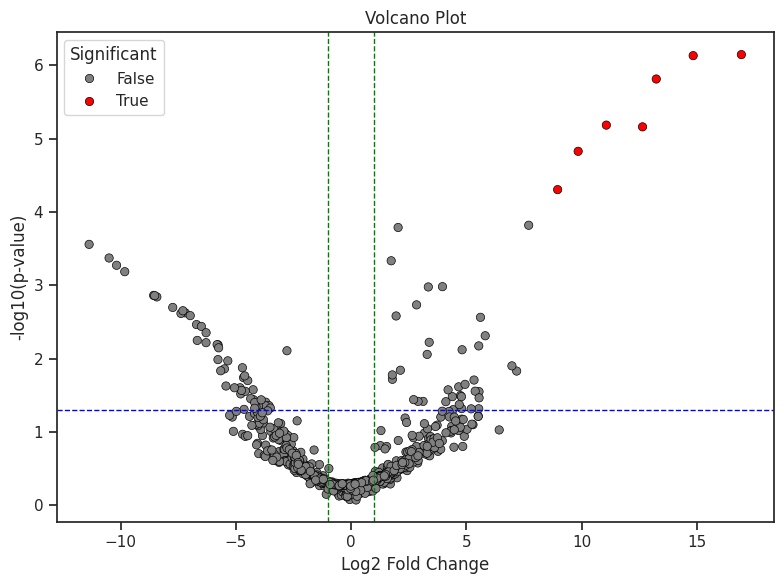

In [ ]:
# Compute -log10(pvalue)
import numpy as np
res['neg_log10_pval'] = -np.log10(res['pvalue'])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=res,
    x="Log2(FC)",
    y="neg_log10_pval",
    hue="Signif",
    palette={True: "red", False: "gray"},
    edgecolor="black"
)

plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
plt.axvline(x=1, color='green', linestyle='--', linewidth=1)
plt.axvline(x=-1, color='green', linestyle='--', linewidth=1)

plt.title("Volcano Plot")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.legend(title="Significant")
plt.tight_layout()
plt.show()

# Pairwise permanova, this part uses R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("vegan")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘permute’

trying URL 'https://cran.rstudio.com/src/contrib/permute_0.9-10.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/vegan_2.7-3.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmprG1KNG/downloaded_packages’


In [ ]:
%%R
library(devtools)

Loading required package: usethis


In [ ]:
%%R
install_github("pmartinezarbizu/pairwiseAdonis/pairwiseAdonis")

ℹ The package "remotes" is required.
✖ Would you like to install it?

1: Yes
2: No

Selection: 1

 Found  1  deps for  0/1  pkgs [⠋] Resolving standard (CRAN/BioC) packages
 Found  1  deps for  0/1  pkgs [⠙] Resolving standard (CRAN/BioC) packages
Checking for 8 new metadata files
 Found  1  deps for  0/1  pkgs [⠹] Resolving standard (CRAN/BioC) packages
⠋ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠸] Resolving standard (CRAN/BioC) packages
⠙ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠼] Resolving standard (CRAN/BioC) packages
⠹ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠴] Resolving standard (CRAN/BioC) packages
⠸ Updating metadata database [0/8] | Downloading [224.84 kB / 3.32 MB]
 Found  1  deps for  0/1  pkgs [⠦] Resolving standard (CRAN/BioC) packages
⠼ Updating metadata database [0/8] | Downloading [669.83 kB / 3.33 MB]
 Found  1  deps fo

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
In addition: Warning message:
`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


In [ ]:
%%R
library(pairwiseAdonis)
library(vegan)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: vegan
Loading required package: permute

Attaching package: ‘permute’

The following object is masked from ‘package:devtools’:

    check

This is vegan 2.7-3
Loading required package: cluster


this part is python code to export the feature_dist, this one Jaccard (change above if you'd like a different one)

In [ ]:
feature_df=feature_dist.to_data_frame()

In [ ]:
feature_df.to_csv('feature_dist.txt', sep='\t')

In [ ]:
%%R
metadata<-read.table("/content/vsearch_outputs/metadata.tsv", header=T)

In [ ]:
%%R
colnames(metadata)

[1] "sample.id" "group"     "mouse"    


make a Group column

In [ ]:
%%R
jac<-read.table("/content/feature_dist.txt")

In [ ]:
%%R
rownames(jac)

 [1] "HFD_1"      "HFD_2"      "HFD_3"      "HFD_4"      "HFD_5"     
 [6] "HFD_6"      "HFD_MRS_1"  "HFD_MRS_10" "HFD_MRS_2"  "HFD_MRS_3" 
[11] "HFD_MRS_4"  "HFD_MRS_5"  "HFD_MRS_6"  "HFD_MRS_7"  "HFD_MRS_8" 
[16] "HFD_MRS_9"  "HFD_M_1"    "HFD_M_10"   "HFD_M_2"    "HFD_M_3"   
[21] "HFD_M_4"    "HFD_M_5"    "HFD_M_6"    "HFD_M_7"    "HFD_M_8"   
[26] "HFD_M_9"    "HFD_R_1"    "HFD_R_10"   "HFD_R_2"    "HFD_R_3"   
[31] "HFD_R_4"    "HFD_R_5"    "HFD_R_6"    "HFD_R_7"    "HFD_R_8"   
[36] "HFD_R_9"    "HFD_S_1"    "HFD_S_10"   "HFD_S_2"    "HFD_S_3"   
[41] "HFD_S_4"    "HFD_S_5"    "HFD_S_6"    "HFD_S_7"    "HFD_S_8"   
[46] "HFD_S_9"    "NC_1"       "NC_10"      "NC_2"       "NC_3"      
[51] "NC_4"       "NC_5"       "NC_6"       "NC_7"       "NC_8"      
[56] "NC_9"      


In [ ]:
%%R
metadata <- metadata[match(rownames(jac), metadata$sample.id), ]

need to make sure the rownames are in the correct order

In [ ]:
%%R
data.frame(rownames(jac), metadata$sample.id)

   rownames.jac. metadata.sample.id
1          HFD_1              HFD_1
2          HFD_2              HFD_2
3          HFD_3              HFD_3
4          HFD_4              HFD_4
5          HFD_5              HFD_5
6          HFD_6              HFD_6
7      HFD_MRS_1          HFD_MRS_1
8     HFD_MRS_10         HFD_MRS_10
9      HFD_MRS_2          HFD_MRS_2
10     HFD_MRS_3          HFD_MRS_3
11     HFD_MRS_4          HFD_MRS_4
12     HFD_MRS_5          HFD_MRS_5
13     HFD_MRS_6          HFD_MRS_6
14     HFD_MRS_7          HFD_MRS_7
15     HFD_MRS_8          HFD_MRS_8
16     HFD_MRS_9          HFD_MRS_9
17       HFD_M_1            HFD_M_1
18      HFD_M_10           HFD_M_10
19       HFD_M_2            HFD_M_2
20       HFD_M_3            HFD_M_3
21       HFD_M_4            HFD_M_4
22       HFD_M_5            HFD_M_5
23       HFD_M_6            HFD_M_6
24       HFD_M_7            HFD_M_7
25       HFD_M_8            HFD_M_8
26       HFD_M_9            HFD_M_9
27       HFD_R_1            

In [ ]:
%%R
results <-pairwise.adonis(jac, metadata$group, perm = 9999)

In [ ]:
%%R
colnames(results)

[1] "pairs"      "Df"         "SumsOfSqs"  "F.Model"    "R2"        
[6] "p.value"    "p.adjusted" "sig"       


In [ ]:
%%R
results[,c(5,1,6)]

           R2            pairs p.value
1  0.15367458   HFD vs HFD_MRS  0.0655
2  0.07924601     HFD vs HFD_M  0.3113
3  0.25496978     HFD vs HFD_R  0.0031
4  0.19901880     HFD vs HFD_S  0.0108
5  0.57197065        HFD vs NC  0.0002
6  0.18285905 HFD_MRS vs HFD_M  0.0062
7  0.15217276 HFD_MRS vs HFD_R  0.0192
8  0.10273535 HFD_MRS vs HFD_S  0.0768
9  0.71165796    HFD_MRS vs NC  0.0001
10 0.29797108   HFD_M vs HFD_R  0.0001
11 0.23882979   HFD_M vs HFD_S  0.0003
12 0.58872027      HFD_M vs NC  0.0001
13 0.18954238   HFD_R vs HFD_S  0.0059
14 0.74069589      HFD_R vs NC  0.0001
15 0.75020549      HFD_S vs NC  0.0001


Corrected pvalues

In [ ]:
%%R
results$p.adjusted <- p.adjust(results$p.value, method = "fdr")


In [ ]:
%%R
results[,c(1,5,6,7)]

              pairs         R2 p.value   p.adjusted
1    HFD vs HFD_MRS 0.15367458  0.0655 0.0755769231
2      HFD vs HFD_M 0.07924601  0.3113 0.3113000000
3      HFD vs HFD_R 0.25496978  0.0031 0.0058125000
4      HFD vs HFD_S 0.19901880  0.0108 0.0147272727
5         HFD vs NC 0.57197065  0.0002 0.0005000000
6  HFD_MRS vs HFD_M 0.18285905  0.0062 0.0093000000
7  HFD_MRS vs HFD_R 0.15217276  0.0192 0.0240000000
8  HFD_MRS vs HFD_S 0.10273535  0.0768 0.0822857143
9     HFD_MRS vs NC 0.71165796  0.0001 0.0003000000
10   HFD_M vs HFD_R 0.29797108  0.0001 0.0003000000
11   HFD_M vs HFD_S 0.23882979  0.0003 0.0006428571
12      HFD_M vs NC 0.58872027  0.0001 0.0003000000
13   HFD_R vs HFD_S 0.18954238  0.0059 0.0093000000
14      HFD_R vs NC 0.74069589  0.0001 0.0003000000
15      HFD_S vs NC 0.75020549  0.0001 0.0003000000
